In [1]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [3]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [4]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [5]:
llm = ChatOpenAI(model='gpt-4.1-mini')

In [6]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [7]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [8]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [9]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    clean_title = title.lower().strip().replace(" ", "_")
    for bad_char in ["?", ":", "/"]:
        clean_title = clean_title.replace(bad_char, "")

    output_dir = Path("MD_Files")
    filename = f"{clean_title}.md"
    output_path = output_dir / filename
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

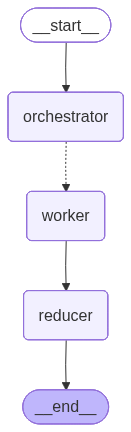

In [10]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [11]:
out = app.invoke({'topic': "Write a blog on Self Attention", "sections": []})

In [12]:
for s in out['sections']:
    print(s)

## Introduction to Self-Attention

Self-attention is a powerful mechanism in modern machine learning that allows models to weigh the importance of different parts of the input data relative to each other. Unlike traditional methods that process data sequentially or focus on fixed-size contexts, self-attention dynamically captures relationships between all elements in a sequence, regardless of their distance.

In natural language processing (NLP), understanding context is critical. Words in a sentence can influence each other in complex ways, and capturing these dependencies—both nearby and far apart—is essential for tasks like translation, summarization, and question answering. Self-attention enables models to look at the entire sentence at once and decide which words to focus on when encoding meaning, making it a cornerstone of architectures such as the Transformer.

By facilitating parallel computation and flexible context integration, self-attention has revolutionized how machines c